# Faster R-CNN on Pascal VOC 2007

Train Faster R-CNN with ResNet50-FPN backbone on Pascal VOC 2007 dataset for object detection.

## VOC Dataset Utilities

First, we need to define the VOC dataset wrapper since we can't import from local files in Kaggle.

In [1]:
"""
Pascal VOC Dataset wrapper for Faster R-CNN training

Converts VOC XML format to Faster R-CNN expected format:
- boxes: [[xmin, ymin, xmax, ymax], ...]
- labels: [class_id, ...]
- image_id: int
"""

import torch
from torch.utils.data import Dataset
from torchvision.datasets import VOCDetection
from torchvision import transforms

# VOC class names (20 classes)
VOC_CLASSES = [
    'aeroplane', 'bicycle', 'bird', 'boat', 'bottle',
    'bus', 'car', 'cat', 'chair', 'cow',
    'diningtable', 'dog', 'horse', 'motorbike', 'person',
    'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]

# Create class name to index mapping (1-indexed, 0 is background)
CLASS_TO_IDX = {cls_name: idx + 1 for idx, cls_name in enumerate(VOC_CLASSES)}


class VOCDatasetWrapper(Dataset):
    """Wrapper for VOC dataset that converts XML annotations to Faster R-CNN format"""

    def __init__(self, root, year='2007', image_set='train', transform=None):
        self.voc_dataset = VOCDetection(
            root=root,
            year=year,
            image_set=image_set,
            download=False
        )
        self.transform = transform

    def __len__(self):
        return len(self.voc_dataset)

    def __getitem__(self, idx):
        img, annotation = self.voc_dataset[idx]

        boxes = []
        labels = []
        areas = []

        objects = annotation['annotation']['object']
        if not isinstance(objects, list):
            objects = [objects]

        for obj in objects:
            class_name = obj['name']
            if class_name not in CLASS_TO_IDX:
                continue

            label = CLASS_TO_IDX[class_name]
            bbox = obj['bndbox']
            xmin = float(bbox['xmin'])
            ymin = float(bbox['ymin'])
            xmax = float(bbox['xmax'])
            ymax = float(bbox['ymax'])

            if xmax <= xmin or ymax <= ymin:
                continue

            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(label)
            areas.append((xmax - xmin) * (ymax - ymin))

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        areas = torch.as_tensor(areas, dtype=torch.float32)
        image_id = torch.tensor([idx])

        target = {
            'boxes': boxes,
            'labels': labels,
            'image_id': image_id,
            'area': areas,
            'iscrowd': torch.zeros((len(labels),), dtype=torch.uint8)
        }

        if self.transform is not None:
            img = self.transform(img)

        return img, target


def collate_fn(batch):
    """Custom collate function for DataLoader"""
    images = []
    targets = []

    for img, target in batch:
        if not isinstance(img, torch.Tensor):
            img = transforms.ToTensor()(img)
        images.append(img)
        targets.append(target)

    return images, targets

print("VOC Dataset utilities defined")

VOC Dataset utilities defined


## Import Libraries

In [2]:
import os
import time
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np

print(f"PyTorch: {torch.__version__}")
print(f"Torchvision: {torchvision.__version__}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.8.0+cu126
Torchvision: 0.23.0+cu126
Device: cuda
GPU: Tesla T4


## Configuration

In [3]:
# ==================== Dataset Path ====================
# IMPORTANT: Set data_root to the PARENT directory of VOCdevkit
# 
# Your dataset structure should be:
#   data_root/
#   └── VOCdevkit/
#       └── VOC2007/
#           ├── Annotations/
#           ├── ImageSets/
#           └── JPEGImages/
#
# Example: If your structure is:
#   /kaggle/input/my-dataset/VOCtrainval_06-Nov-2007/VOCdevkit/VOC2007/
# Then set:
#   data_root = '/kaggle/input/my-dataset/VOCtrainval_06-Nov-2007'

# Modify this path (should point to parent of VOCdevkit):
data_root = '/kaggle/input/cvdl-hw2-datasets/data/VOCtrainval_06-Nov-2007'

# ==================== Training Config ====================
config = {
    'data_root': data_root,
    'num_epochs': 20,
    'batch_size': 4,
    'learning_rate': 0.005,
    'momentum': 0.9,
    'weight_decay': 0.0005,
    'num_workers': 2,
    'save_dir': 'weights',
    'results_dir': 'results',
    'print_freq': 50
}

os.makedirs(config['save_dir'], exist_ok=True)
os.makedirs(config['results_dir'], exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"\nConfig:")
print(f"  Data root: {config['data_root']}")
print(f"  Epochs: {config['num_epochs']}")
print(f"  Batch size: {config['batch_size']}")
print(f"  Learning rate: {config['learning_rate']}")

Device: cuda

Config:
  Data root: /kaggle/input/cvdl-hw2-datasets/data/VOCtrainval_06-Nov-2007
  Epochs: 20
  Batch size: 4
  Learning rate: 0.005


## Load Dataset

**Upload Steps:**

1. **Compress dataset** (on local machine):
   - Compress the entire `VOCtrainval_06-Nov-2007` folder to .zip or .tar.gz

2. **Upload to Kaggle**:
   - Kaggle -> Your Work -> Datasets -> New Dataset
   - Upload and name it (e.g., `voc-2007-trainval`)

3. **Add to Notebook**:
   - Right panel "Add data" -> Search your dataset -> Add
   - Path will show as: `/kaggle/input/your-dataset-name/...`

4. **Set correct path**:
   - Your uploaded structure: `your-dataset/data/VOCtrainval_06-Nov-2007/VOCdevkit/VOC2007/`
   - Set `data_root` to the PARENT of `VOCdevkit`
   - Example: `data_root = '/kaggle/input/your-dataset/data/VOCtrainval_06-Nov-2007'`
   - NOT: `'/kaggle/input/your-dataset/data/VOCtrainval_06-Nov-2007/VOCdevkit'`

In [4]:
# Verify path exists
print(f"Checking dataset path: {config['data_root']}")
if not os.path.exists(config['data_root']):
    print(f"ERROR: Path does not exist!")
    print(f"       Please check data_root setting above")
    print(f"       Current path: {config['data_root']}")
    raise FileNotFoundError(f"Dataset path not found: {config['data_root']}")
else:
    print(f"OK: Path exists")
    
    # Check for VOCdevkit folder
    vocdevkit_path = os.path.join(config['data_root'], 'VOCdevkit')
    if not os.path.exists(vocdevkit_path):
        print(f"ERROR: VOCdevkit folder not found in {config['data_root']}")
        raise FileNotFoundError(f"VOCdevkit not found. Expected: {vocdevkit_path}")
    else:
        print(f"OK: VOCdevkit folder found")
    
    # Check for VOC2007 folder
    voc_path = os.path.join(vocdevkit_path, 'VOC2007')
    if not os.path.exists(voc_path):
        print(f"ERROR: VOC2007 folder not found in {vocdevkit_path}")
        raise FileNotFoundError(f"VOC2007 not found. Expected: {voc_path}")
    else:
        print(f"OK: VOC2007 folder found")

print("\nLoading Pascal VOC 2007 dataset...")
dataset = VOCDatasetWrapper(
    root=config['data_root'],
    year='2007',
    image_set='trainval',
    transform=None
)
print(f"Dataset loaded: {len(dataset)} images")

data_loader = DataLoader(
    dataset,
    batch_size=config['batch_size'],
    shuffle=True,
    num_workers=config['num_workers'],
    collate_fn=collate_fn
)

print(f"DataLoader created: {len(data_loader)} batches")

Checking dataset path: /kaggle/input/cvdl-hw2-datasets/data/VOCtrainval_06-Nov-2007
OK: Path exists
OK: VOCdevkit folder found
OK: VOC2007 folder found

Loading Pascal VOC 2007 dataset...
Dataset loaded: 5011 images
DataLoader created: 1253 batches


## Training Functions

In [5]:
def train_one_epoch(model, optimizer, data_loader, device, epoch, print_freq=50):
    model.train()
    total_loss = 0
    num_batches = 0

    for i, (images, targets) in enumerate(data_loader):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        total_loss += losses.item()
        num_batches += 1

        if (i + 1) % print_freq == 0:
            avg_loss = total_loss / num_batches
            print(f"  [{epoch}] [{i+1}/{len(data_loader)}] Loss: {losses.item():.4f} | Avg: {avg_loss:.4f}")

    return total_loss / num_batches

## Visualization

In [6]:
def save_loss_curve(losses, save_path):
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(losses) + 1), losses, 'b-', linewidth=2, marker='o')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.title('Faster R-CNN Training Loss Curve', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

## Create Model

In [7]:
print("Creating Faster R-CNN model...")
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
    weights='DEFAULT'  # Pre-trained on COCO
)

# Replace the classifier head for VOC dataset (21 classes)
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

num_classes = 21  # 20 VOC classes + background
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

model.to(device)

num_params = sum(p.numel() for p in model.parameters())
num_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parameters: {num_params:,}")
print(f"Trainable: {num_trainable:,}")

params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.SGD(
    params,
    lr=config['learning_rate'],
    momentum=config['momentum'],
    weight_decay=config['weight_decay']
)

lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

Creating Faster R-CNN model...
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 173MB/s]


Parameters: 41,396,536
Trainable: 41,174,136


## Training

In [8]:
print(f"Training for {config['num_epochs']} epochs...\n")

train_losses = []
best_loss = float('inf')
start_time = time.time()

for epoch in range(1, config['num_epochs'] + 1):
    epoch_start = time.time()
    
    avg_loss = train_one_epoch(
        model, optimizer, data_loader, device, epoch,
        print_freq=config['print_freq']
    )
    
    train_losses.append(avg_loss)
    lr_scheduler.step()
    
    epoch_time = time.time() - epoch_start
    current_lr = optimizer.param_groups[0]['lr']
    
    print(f"\nEpoch {epoch}/{config['num_epochs']}:")
    print(f"  Loss: {avg_loss:.4f} | LR: {current_lr:.6f} | Time: {epoch_time:.1f}s")
    print("-" * 60)
    
    if avg_loss < best_loss:
        best_loss = avg_loss
        best_model_path = os.path.join(config['save_dir'], 'faster_rcnn_best.pth')
        torch.save(model.state_dict(), best_model_path)
        print(f"  Best model saved ({best_loss:.4f})")
    
    if epoch % 5 == 0:
        checkpoint = os.path.join(config['save_dir'], f'faster_rcnn_epoch_{epoch}.pth')
        torch.save(model.state_dict(), checkpoint)
        print(f"  Checkpoint saved")

total_time = time.time() - start_time
print(f"\nTraining complete: {total_time/60:.1f} min")
print(f"Best loss: {best_loss:.4f}")

final_model_path = os.path.join(config['save_dir'], 'faster_rcnn_final.pth')
torch.save(model.state_dict(), final_model_path)

Training for 20 epochs...

  [1] [50/1253] Loss: 0.6509 | Avg: 0.8563
  [1] [100/1253] Loss: 0.7680 | Avg: 0.7574
  [1] [150/1253] Loss: 0.6948 | Avg: 0.7062
  [1] [200/1253] Loss: 0.8014 | Avg: 0.6724
  [1] [250/1253] Loss: 0.2903 | Avg: 0.6280
  [1] [300/1253] Loss: 0.5515 | Avg: 0.6002
  [1] [350/1253] Loss: 0.5100 | Avg: 0.5715
  [1] [400/1253] Loss: 0.7320 | Avg: 0.5499
  [1] [450/1253] Loss: 0.2596 | Avg: 0.5330
  [1] [500/1253] Loss: 0.2874 | Avg: 0.5216
  [1] [550/1253] Loss: 0.4009 | Avg: 0.5094
  [1] [600/1253] Loss: 0.1327 | Avg: 0.4999
  [1] [650/1253] Loss: 0.4259 | Avg: 0.4895
  [1] [700/1253] Loss: 0.4079 | Avg: 0.4831
  [1] [750/1253] Loss: 0.6844 | Avg: 0.4744
  [1] [800/1253] Loss: 0.3745 | Avg: 0.4677
  [1] [850/1253] Loss: 0.2937 | Avg: 0.4617
  [1] [900/1253] Loss: 0.4864 | Avg: 0.4568
  [1] [950/1253] Loss: 0.5804 | Avg: 0.4535
  [1] [1000/1253] Loss: 0.3366 | Avg: 0.4476
  [1] [1050/1253] Loss: 0.3243 | Avg: 0.4435
  [1] [1100/1253] Loss: 0.4216 | Avg: 0.4398
  [

## Results

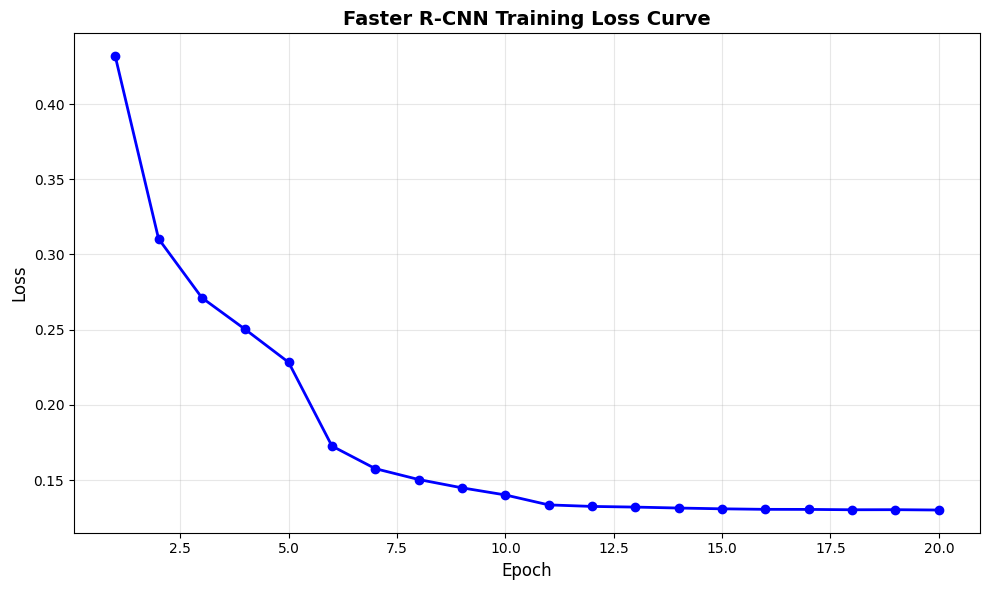


Final Results:
  Final Loss: 0.1301
  Best Loss:  0.1301


In [9]:
loss_curve_path = os.path.join(config['results_dir'], 'faster_rcnn_loss.png')
save_loss_curve(train_losses, loss_curve_path)

print(f"\nFinal Results:")
print(f"  Final Loss: {train_losses[-1]:.4f}")
print(f"  Best Loss:  {best_loss:.4f}")

## Download (Kaggle)

In [10]:
import shutil

try:
    shutil.copy(best_model_path, '/kaggle/working/')
    shutil.copy(final_model_path, '/kaggle/working/')
    shutil.copy(loss_curve_path, '/kaggle/working/')
    print("Files copied to /kaggle/working/")
except:
    print("Not in Kaggle environment")

Files copied to /kaggle/working/
